<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/10_computer_vision/cnn_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNN)

Convolutional Neural Networks (CNNs) are specialized neural networks designed for image data.

CNNs automatically learn important features such as:

- Edges
- Shapes
- Textures
- Patterns

CNNs are widely used in:

- Face Recognition
- Medical Imaging
- Skin Cancer Detection
- Brain Tumor Classification
- Autonomous Vehicles

In this notebook, we will learn how CNNs work and build our first image classifier.

## Why Not Use Traditional Neural Networks?

Consider a color image of size:

224 × 224 × 3

This image contains:

224 × 224 × 3 = 150,528 values

A traditional neural network would require a huge number of parameters.

CNNs solve this problem by learning local image features using convolutional filters.

## CNN Architecture

A typical CNN contains:

1. Convolution Layer
2. Activation Function (ReLU)
3. Pooling Layer
4. Fully Connected Layer
5. Output Layer

The network gradually learns more complex image features.

In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Loading a Sample Dataset

We will use the Fashion MNIST dataset.

The dataset contains grayscale images of:

- T-shirts
- Shoes
- Bags
- Dresses
- Other clothing items

This dataset is commonly used for learning Computer Vision.

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


## Visualizing Sample Images

Let's view some training images.

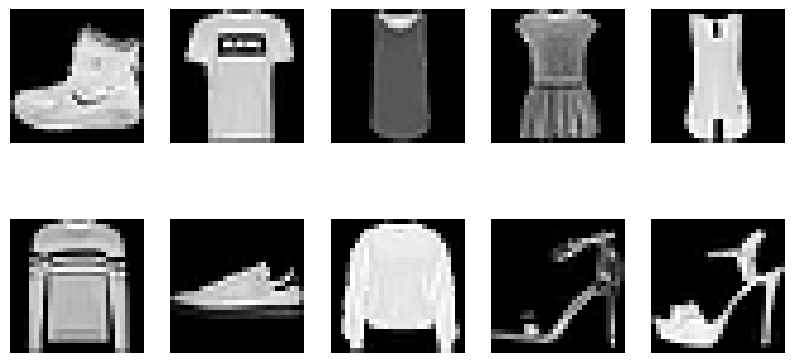

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.axis("off")

plt.show()

## Data Preprocessing

Deep learning models perform better when pixel values are normalized.

Original pixel range:

0 – 255

Normalized range:

0 – 1

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Reshaping Images

CNNs expect images in the format:

(height, width, channels)

Since Fashion MNIST is grayscale, the number of channels is 1.

In [5]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)

(60000, 28, 28, 1)


## Building a CNN Model

The CNN consists of:

- Convolution Layer
- Max Pooling Layer
- Dense Layers

This is a basic CNN architecture.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

Before training, we define:

- Optimizer
- Loss Function
- Evaluation Metric

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training the Model

We train the CNN for a few epochs.

An epoch means one complete pass through the training dataset.

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.8549 - loss: 0.4113 - val_accuracy: 0.8837 - val_loss: 0.3250
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8985 - loss: 0.2786 - val_accuracy: 0.8951 - val_loss: 0.2859
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9152 - loss: 0.2318 - val_accuracy: 0.9092 - val_loss: 0.2516


## Evaluating the Model

In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9019 - loss: 0.2659
Test Accuracy: 0.9018999934196472


## Visualizing Training Performance

Let's observe how the model learned during training.

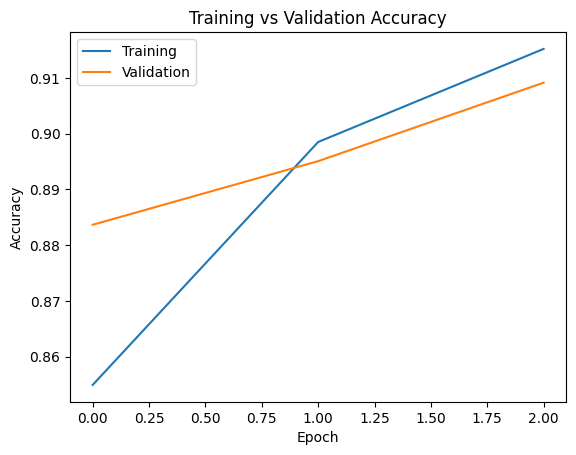

In [10]:
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

# Summary

In this notebook I learned:

- What CNNs are
- Why CNNs are used for images
- How convolution layers work
- How pooling layers work
- How to build a CNN using TensorFlow
- How to train a CNN
- How to evaluate CNN performance

CNNs are the foundation of modern Computer Vision systems and are widely used in medical imaging applications such as skin cancer classification and brain tumor analysis.